# Training

In [1]:
# Imports for Training #

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
import tensorflow as tf
import keras.backend as K
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, BatchNormalization, Concatenate, Add, Activation
from tensorflow.keras.activations import relu, sigmoid
from tensorflow.keras.models import Model
from qkeras.qlayers import QConv2D, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu

I0000 00:00:1777165261.244585   25967 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777165261.267142   25967 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777165261.796460   25967 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [82]:
print(tf.keras.__version__)

3.14.0


In [2]:
# Constants #

IMAGE_X = 256
IMAGE_Y = 256

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

SCALE_FACTOR = 8

LABEL_X = IMAGE_X // SCALE_FACTOR
LABEL_Y = IMAGE_Y // SCALE_FACTOR

MIN_NUM_GAUSSIANS = 2
MAX_NUM_GAUSSIANS = 5

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

THRESHOLD = 0.5

SEED = 0
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

In [3]:
# Generate Gaussian Functions #

def img_gen(VERBOSE: bool = False) -> tuple:

    img = np.zeros(shape=(IMAGE_Y, IMAGE_X, 1))
    params = []

    num_gaussians = np.random.randint(low=MIN_NUM_GAUSSIANS, high=MAX_NUM_GAUSSIANS + 1)
    for _ in range(num_gaussians):

        # Randomize params
        center_x = np.random.randint(low=0 + GAUSSIAN_X // 2, high=IMAGE_X - GAUSSIAN_X // 2)
        center_y = np.random.randint(low=0 + GAUSSIAN_Y // 2, high=IMAGE_Y - GAUSSIAN_Y // 2)

        std_x = rng.uniform(MIN_STD_X, MAX_STD_X)
        std_y = rng.uniform(MIN_STD_Y, MAX_STD_Y)
        theta = rng.uniform(MIN_THETA, MAX_THETA)
        
        intensity = MIN_INTENSITY + rng.random() * (MAX_INTENSITY - MIN_INTENSITY)
        
        # Generate Gaussian
        params.append((center_x, center_y, std_x, std_y, theta, intensity))
        gaussian = np.array(gaussian_gen(center_x, center_y, std_x, std_y, theta))

        # Add Gaussian to img
        img +=  gaussian * intensity

    # Soft gaussian label
    SOFT_LABEL_SIGMA = 0.75
    label = make_soft_label(params, LABEL_Y, LABEL_X, SCALE_FACTOR, sigma=SOFT_LABEL_SIGMA)

    # Convert to 8 bit int
    label = (label * 255).astype(np.uint8)
    img = (np.clip(img, 0.0, 1.0) * 255).astype(np.uint8)

    if VERBOSE:
        print(f"[Target Gaussians #]: {str(num_gaussians)}")
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )

    return (img, label, params)

X, Y = np.meshgrid(
    np.arange(IMAGE_X),
    np.arange(IMAGE_Y)
)
def gaussian_gen(center_x: float, center_y: float, std_x: float, std_y: float, theta: float, X=X, Y=Y) -> np.ndarray:

    cos_theta_sqrd = np.power(np.cos(theta),2)
    sin_theta_sqrd = np.power(np.sin(theta),2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)
    
    std_x_sqrd = np.power(std_x, 2)
    std_y_sqrd = np.power(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(-(a * (X - center_x)**2 + 2*b * (X - center_x) * (Y - center_y) + c * (Y - center_y)**2))

    return np.expand_dims(gaussian, -1)

def make_soft_label(params, label_h, label_w, scale_factor, sigma=0.75):
    yy, xx = np.meshgrid(np.arange(label_h), np.arange(label_w), indexing='ij')
    label = np.zeros((label_h, label_w), dtype=np.float32)
    for center_x, center_y, std_x, std_y, theta, intensity in params:
        gx = center_x / scale_factor
        gy = center_y / scale_factor
        bump = np.exp(-((xx - gx)**2 + (yy - gy)**2) / (2 * sigma**2))
        label = np.maximum(label, bump)
    return label[..., None]

def img_visualization_one(img: np.ndarray, label: np.ndarray, params: list = None, threshold: int = THRESHOLD) -> None:
    
    img = np.squeeze(img)
    rgb_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Coords of Gaussians:
    for x in range(LABEL_X):
        for y in range(LABEL_Y):
            if label[y, x,] >= threshold:
                
                top_left = (x * SCALE_FACTOR - GAUSSIAN_X // 2, y * SCALE_FACTOR - GAUSSIAN_Y // 2)
                bottom_right = (x * SCALE_FACTOR + GAUSSIAN_X // 2, y * SCALE_FACTOR + GAUSSIAN_Y // 2)
                color = (0, 200, 200)
                thickness = 2
                
                cv2.rectangle(rgb_image, top_left, bottom_right, color, thickness)

    if params != None:
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )
    
    plt.imshow(rgb_image)
    plt.axis('off')

def img_visualization_two(img: np.ndarray, label: np.ndarray, params: list = None) -> None:

    if params != None:
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(label, cmap='gray')
    plt.axis('off')

[(c_x, c_y)]: (71 , 141) [(s_x, s_y)]: (8.821770123928726, 6.618720282583222) [Theta]: 0.13 [I]: 0.21 
[(c_x, c_y)]: (216, 91 ) [(s_x, s_y)]: (9.879621435201635, 10.47653346366633) [Theta]: 1.91 [I]: 0.64 


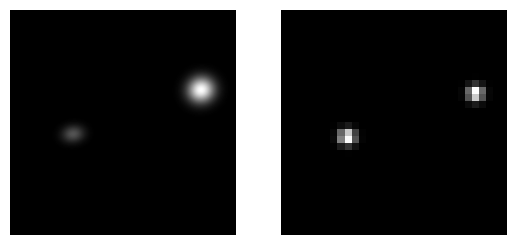

In [4]:
# Test Generate Functions #

img, label, params = img_gen()
img_visualization_two(img, label, params)

In [5]:
# Generate Training Dataset #
# TODO: look into using tf.data.Dataset.from_generator
# TODO: look into parallelizing
SAMPLE_COUNT = 10000


img_arr = np.empty((SAMPLE_COUNT, IMAGE_Y, IMAGE_X, 1), dtype=np.float32)
label_arr = np.empty((SAMPLE_COUNT, LABEL_Y, LABEL_X, 1), dtype=np.float32)

for i in tqdm(range(SAMPLE_COUNT)):
        img, label, _ = img_gen()
        img_arr[i] = img.astype(np.float32) / 256.0         # Normalize values to [0, 1)
        label_arr[i] = label.astype(np.float32) / 256.0     # Normalize values to [0, 1)

print(f'[Images Shape]: {img_arr.shape}')
print(f'[Labels Shape]: {label_arr.shape}')

100%|██████████| 10000/10000 [00:09<00:00, 1090.82it/s]

[Images Shape]: (10000, 256, 256, 1)
[Labels Shape]: (10000, 32, 32, 1)


In [6]:
# Generate Validation Dataset for Training #
# TODO: look into using tf.data.Dataset.from_generator
# TODO: look into parallelizing
VAL_COUNT = 1000


img_arr_val = np.empty((VAL_COUNT, IMAGE_Y, IMAGE_X, 1), dtype=np.float32)
label_arr_val = np.empty((VAL_COUNT, LABEL_Y, LABEL_X, 1), dtype=np.float32)

for i in tqdm(range(VAL_COUNT)):
        img, label, _ = img_gen()
        img_arr_val[i] = img.astype(np.float32) / 256.0         # Normalize values to [0, 1)
        label_arr_val[i] = label.astype(np.float32) / 256.0     # Normalize values to [0, 1)

print(f'[Images Shape]: {img_arr_val.shape}')
print(f'[Labels Shape]: {label_arr_val.shape}')        

100%|██████████| 1000/1000 [00:00<00:00, 1101.28it/s]

[Images Shape]: (1000, 256, 256, 1)
[Labels Shape]: (1000, 32, 32, 1)


In [7]:
# Convert Data to TF Dataset #
BATCH_SIZE = 50

dataset = (
    tf.data.Dataset.from_tensor_slices(
        (img_arr, label_arr)
    )
    .shuffle(SAMPLE_COUNT, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices(
        (img_arr_val, label_arr_val)
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

W0000 00:00:1777165279.500715   25967 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [8]:
# Qkeras Model Architecture #
TOTAL_BITS = 8
INTEGER_BITS = 0


w_quant = quantized_bits(TOTAL_BITS, INTEGER_BITS, symmetric=False, keep_negative=True, alpha=1)
relu_quant = quantized_relu(TOTAL_BITS, INTEGER_BITS, alpha=1)

input_layer = Input(shape=(IMAGE_Y, IMAGE_X, 1))

x = QConv2D(filters=4, kernel_size=3, strides=2, padding='same', use_bias=False, name="qconv2d_1_1",
    kernel_quantizer=w_quant,
    kernel_initializer='lecun_uniform'
)(input_layer)
# x = BatchNormalization(name="b_1_1")(x)
x = QActivation(relu_quant, name="qact_1_1")(x)
y = QConv2D(filters=4, kernel_size=3, padding='same', use_bias=False, name="qconv2d_1_2",
    kernel_quantizer=w_quant,
    kernel_initializer='lecun_uniform'
)(x)
# y = BatchNormalization(name="b_1_2")(y)
x = Add(name="add_1")([x, y])
x = QActivation(relu_quant, name="qact_1_2")(x)

x = QConv2D(filters=6, kernel_size=3, strides=2, padding='same', use_bias=False, name="qconv2d_2_1",
    kernel_quantizer=w_quant,
    kernel_initializer='lecun_uniform'
)(x)
# x = BatchNormalization(name="b_2_1")(x)
x = QActivation(relu_quant, name="qact_2_1")(x)
y = QConv2D(filters=6, kernel_size=3, padding='same', use_bias=False, name="qconv2d_2_2",
    kernel_quantizer=w_quant,
    kernel_initializer='lecun_uniform'
)(x)
# y = BatchNormalization(name="b_2_2")(y)
x = Add(name="add_2")([x, y])
x = QActivation(relu_quant, name="qact_2_2")(x)

x = QConv2D(filters=8, kernel_size=3, strides=2, padding='same', use_bias=False, name="qconv2d_3_1",
    kernel_quantizer=w_quant,
    kernel_initializer='lecun_uniform'
)(x)
# x = BatchNormalization(name="b_3_1")(x)
x = QActivation(relu_quant, name="qact_3_1")(x)
y = QConv2D(filters=8, kernel_size=3, padding='same', use_bias=False, name="qconv2d_3_2",
    kernel_quantizer=w_quant,
    kernel_initializer='lecun_uniform'
)(x)
# y = BatchNormalization(name="b_3_2")(y)
x = Add(name="add_3")([x, y])
x = QActivation(relu_quant, name="qact_3_2")(x)

x = Conv2D(8, 1, padding='same', use_bias=True, name="qconv2d_4")(x)
x = Activation(relu, name="qact_4")(x)

x_prob = Conv2D(1, 1, padding='same', use_bias=True, name="qconv2d_5")(x)
x_prob = Activation(sigmoid, name="sigmoid_out")(x_prob)

baby_yolo_qk = Model(inputs=input_layer, outputs=x_prob, name='baby_yolo')

In [10]:
# Tensorflow Functions #
POS_WEIGHT = 5.0
NEG_WEIGHT = 1.0

def loss_wbce(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    
    bce = -(y_true * tf.math.log(y_pred) +
            (1.0 - y_true) * tf.math.log(1.0 - y_pred))
    weights = y_true * POS_WEIGHT + (1.0 - y_true) * NEG_WEIGHT
    
    return tf.reduce_mean(weights * bce)

In [ ]:
# Train or Load #
TRAIN_MODEL = True
LOAD_MODEL = False

MODEL_NAME = '[FOLO]_[Generated]_[256]_Q.keras'
NUM_EPOCHS = 100

EARLY_STOPPING_PATIENCE = 10
MIN_DELTA = 1e-4

if TRAIN_MODEL and LOAD_MODEL:
    print("Are you sure you want to Train & Load ?")

elif TRAIN_MODEL:
    adam_optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-3,
        global_clipnorm=1.0,
    )
    baby_yolo_qk.compile(
        optimizer=adam_optimizer,
        loss=loss_wbce,
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        min_delta=MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1,
    )

    history = baby_yolo_qk.fit(
        dataset,
        validation_data=val_dataset,
        epochs=NUM_EPOCHS,
        callbacks=[early_stop, reduce_lr],
        verbose=1,
    )

elif LOAD_MODEL:
    # from qkeras.utils import _add_supported_quantized_objects
    co = {}
    # _add_supported_quantized_objects(co)
    co['loss_wbce'] = loss_wbce
    baby_yolo_tf = tf.keras.models.load_model(f'../Models/{MODEL_NAME}', custom_objects=co)

baby_yolo_tf.summary()

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - loss: 0.5551 - val_loss: 0.3946 - learning_rate: 0.0010
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.3028 - val_loss: 0.2245 - learning_rate: 0.0010
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.1749 - val_loss: 0.1352 - learning_rate: 0.0010
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.1130 - val_loss: 0.0944 - learning_rate: 0.0010
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0845 - val_loss: 0.0752 - learning_rate: 0.0010
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0705 - val_loss: 0.0651 - learning_rate: 0.0010
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0628 - val_loss: 0.0592 - learning_rate: 0.0010
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0580 - val_loss: 0.0555 - learning_rate: 0.0010
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 0.0549 - val_loss: 0.0529 - learn

Model: "baby_yolo"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1_1 (Conv2D) │ (None, 128, 128,  │         36 │ input_layer_1[0]… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_1_1             │ (None, 128, 128,  │          0 │ conv2d_1_1[0][0]  │
│ (Activation)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1_2 (Conv2D) │ (None, 128, 128,  │        144 │ act_1_1[0][0]     │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ act_1_1[0][0],    │
│                     │ 4)                │            │ conv2d_1_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_1_2             │ (None, 128, 128,  │          0 │ add_1[0][0]       │
│ (Activation)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2_1 (Conv2D) │ (None, 64, 64, 6) │        216 │ act_1_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_2_1             │ (None, 64, 64, 6) │          0 │ conv2d_2_1[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2_2 (Conv2D) │ (None, 64, 64, 6) │        324 │ act_2_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64, 6) │          0 │ act_2_1[0][0],    │
│                     │                   │            │ conv2d_2_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_2_2             │ (None, 64, 64, 6) │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3_1 (Conv2D) │ (None, 32, 32, 8) │        432 │ act_2_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_3_1             │ (None, 32, 32, 8) │          0 │ conv2d_3_1[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3_2 (Conv2D) │ (None, 32, 32, 8) │        576 │ act_3_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 32, 32, 8) │          0 │ act_3_1[0][0],    │
│                     │                   │            │ conv2d_3_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ act_3_2             │ (None, 32, 32, 8) │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32, 8) │         72 │ act_3_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_out            │ (None, 32, 32, 8) │          0 │ conv2d_4[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,809 (7.07 KB)

 Trainable params: 1,809 (7.07 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Save Model #
SAVE_MODEL = True

if SAVE_MODEL:
    baby_yolo_tf.save(f'../Models/{MODEL_NAME}', include_optimizer=False)

In [47]:
# Predict on Validation Set #
predictions_qk = baby_yolo_qk.predict(img_arr_val)
predictions_tf = baby_yolo_tf.predict(img_arr_val)

print(f'[Validation Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_qk.shape}')
print(f'[Prediction Shape]: {predictions_tf.shape}')

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[Validation Shape]: (1000, 256, 256, 1)
[Prediction Shape]: (1000, 32, 32, 1)
[Prediction Shape]: (1000, 32, 32, 1)


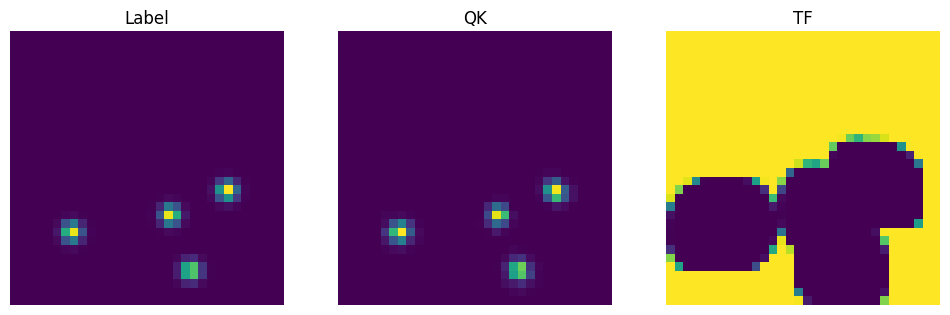

In [73]:
# Compare Predictions #
index = np.random.randint(low=0, high=VAL_COUNT)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
im0 = axes[0].imshow(label_arr_val[index], cmap='viridis', interpolation='none')
axes[0].set_title('Label')
axes[0].axis('off')

im1 = axes[1].imshow(predictions_qk[index], cmap='viridis', interpolation='none')
axes[1].set_title('QK')
axes[1].axis('off')

im2 = axes[2].imshow(predictions_tf[index], cmap='viridis', interpolation='none')
axes[2].set_title('TF')
axes[2].axis('off')
plt.show()

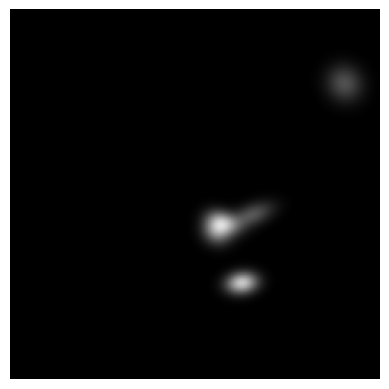

In [46]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

img_visualization_one(img_arr_val[index], predictions_tf[index])

# HLS4ML

In [80]:
# HLS4ML Config #
import hls4ml
from hls4ml.utils import config_from_keras_model
from pprint import pprint

config = config_from_keras_model(baby_yolo_qk, granularity='model', backend='Vitis')

# config['Flows'] = ['vitis:fifo_depth_optimization']
# hls4ml.model.optimizer.get_optimizer('vitis:fifo_depth_optimization').configure(profiling_fifo_depth=100_000)

# config['Model']['Strategy'] = 'Resource'
# config['Model']['PipelineStyle'] = 'pipeline'

# config["Model"]["ReuseFactor"] = 8
# for layer_cfg in config["LayerName"].values():
#     if "ReuseFactor" in layer_cfg:
#         layer_cfg["ReuseFactor"] = 8

# for layer in config['LayerName']:
#     if layer.startswith('conv2d') and layer not in ['conv2d_4', 'conv2d_5']:
#         precision = config['LayerName'][layer].get('Precision', {})
#         for key in precision:
#             if precision[key] == 'auto':
#                 precision[key] = 'fixed<8,0>'
#     if layer.startswith('act_'):
#         config['LayerName'][layer]['Precision']['result'] = 'fixed<8,0>'
        
pprint(config)

{'Model': {'BramFactor': 1000000000,
           'Precision': {'default': 'fixed<16,6>'},
           'ReuseFactor': 1,
           'Strategy': 'Latency',
           'TraceOutput': False}}


In [81]:
# Compile & Predict #
hls_model = hls4ml.converters.convert_from_keras_model(
    baby_yolo_qk,
    hls_config=config,
    output_dir='../folo_hls4ml',
    io_type='io_stream',
    backend='Vitis',
    part='xcku035-fbva676-2-e',
    project_name='folo'
)

hls_model.compile()
 
predictions_hls4ml = hls_model.predict(img_arr_val).reshape(VAL_COUNT, LABEL_Y, LABEL_X)

print(f'[Validation Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_hls4ml.shape}')

/home/pujan/Research/Rheed-FOLO/.venv/lib/python3.12/site-packages/hls4ml/utils/qinterval.py:54: UserWarning: max is not a multiple of delta. Bit-exactness may be compromised.
  warn('max is not a multiple of delta. Bit-exactness may be compromised.')
/home/pujan/Research/Rheed-FOLO/.venv/lib/python3.12/site-packages/hls4ml/utils/qinterval.py:58: UserWarning: min is not a multiple of delta. Bit-exactness may be compromised.
  warn('min is not a multiple of delta. Bit-exactness may be compromised.')


ValueError: Layer input_layer (Input) unexpected input layer chain.

In [ ]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

img_visualization_one(img_arr_val[index], predictions_hls4ml[index])

In [ ]:
# Build Model #
# vitis_hls build_prj.tcl 
# vitis-run --mode hls --tcl build_prj.tcl

# hls_model.build()

In [ ]:
# View Report #

hls4ml.report.read_vivado_report('../folo_hls4ml')